In [11]:
!pip install einops

In [12]:
import numpy as np
import torch
from model import FullModelHAT
from dataset import RescueNetDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import sys
import os

# current file (or notebook working dir)
base_dir = os.getcwd()

segmenter_path = os.path.join(base_dir, "segmenter")

sys.path.insert(0, segmenter_path)
# sys.path.append("/notebooks/segmenter")
from segmenter.segm.model.factory import create_segmenter


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model1
model1 = FullModelHAT(num_classes=11).to(device)
checkpoint1 = "rescuenet_seg_V13.pth"
ckpt = torch.load(checkpoint1, map_location=device)
model1.load_state_dict(ckpt['model_state'])
model1.eval()
print(checkpoint1)


#Model 2
model_cfg = {
        "backbone": "vit_small",
        "normalization": "vit",

        "image_size": (384, 384),
        "patch_size": 16,

        "d_model": 384,
        "n_heads": 6,
        "n_layers": 12,

        "distilled": False,

        "decoder": {
            "name": "mask_transformer",
            "n_layers": 2,
            "drop_path_rate": 0.1,
            "dropout": 0.0,
        },

        "n_cls": 11,
    }

model2 = create_segmenter(model_cfg).to(device)
checkpoint2 = "./segmenter/segmeter_s1.pth"
ckpt = torch.load(checkpoint2, map_location=device)
model2.load_state_dict(ckpt['model_state'])
model2.eval()
print(checkpoint2)


#Dataset
root = "./rescuenet"
image_size = (384, 384)
ignore_index=0

test_dataset   = RescueNetDataset(root=root, split='test', image_size=image_size, augment=False)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
    # num_workers=4,
    # pin_memory=True,
    # persistent_workers=True,
)

CLASS_COLORS = np.array([
    [0, 0, 0],        # Background

    [40, 120, 200],   # Water → blue

    [200, 200, 210],  # Building_No_Damage → light cool gray
    [255, 230, 80],   # Building_Minor_Damage → yellow
    [255, 150, 40],   # Building_Major_Damage → orange
    [220, 40, 40],    # Building_Total_Destruction → red

    [120, 60, 200],   # Vehicle → purple (NOT green anymore)

    [60, 60, 60],     # Road-Clear → dark gray
    [170, 90, 30],    # Road-Blocked → strong brown (far from gray)

    [20, 160, 60],    # Tree → green (clearly different from vehicle now)

    [0, 200, 200]     # Pool → cyan (not same as water)
], dtype=np.uint8)


def mask_to_color(mask):
    return CLASS_COLORS[mask]

def show_validation_examples(model, val_loader, device, num_samples=3):
    model.eval()
    images = []

    with torch.no_grad():
        for item in val_loader:
            img  = item["image"].to(device)
            mask = item["classification"].to(device)
            edge = item["boundary"].to(device)

            outputs = model(img)
            if len(outputs) == 3:
                pred_mask, _, pred_edge = outputs
            else:
                pred_mask, pred_edge = outputs

            pred_mask = torch.argmax(pred_mask, dim=1)
            pred_edge = (torch.sigmoid(pred_edge) > 0.8).float()
            # pred_edge = torch.sigmoid(pred_edge)

            B = img.shape[0]

            for b in range(B):
                mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(3,1,1)
                std  = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(3,1,1)

                img_denorm = img[b] * std + mean
                image_np = img_denorm.permute(1, 2, 0).cpu().numpy()
                image_np = np.clip(image_np, 0, 1)
                image_vis = (image_np * 255).astype(np.uint8)

                gt_mask_raw = mask[b].cpu().numpy()
                pr_mask_raw = pred_mask[b].cpu().numpy()

                gt_mask = mask_to_color(gt_mask_raw)
                pr_mask = mask_to_color(pr_mask_raw)

                # ignore background (class 0)
                gt_overlay = image_vis.copy()
                pr_overlay = image_vis.copy()

                gt_overlay[gt_mask_raw != 0] = (
                    0.5 * image_vis[gt_mask_raw != 0] + 0.5 * gt_mask[gt_mask_raw != 0]
                ).astype(np.uint8)

                pr_overlay[pr_mask_raw != 0] = (
                    0.5 * image_vis[pr_mask_raw != 0] + 0.5 * pr_mask[pr_mask_raw != 0]
                ).astype(np.uint8)

                gt_edge = edge[b].squeeze().cpu().numpy()
                pr_edge = pred_edge[b].squeeze().cpu().numpy()

                images.append((image_vis, gt_overlay, pr_overlay, gt_edge, pr_edge))

            if len(images) >= num_samples:
                break

    fig, axs = plt.subplots(num_samples, 5, figsize=(20, 5 * num_samples))
    titles = ["Image", "GT Mask", "Pred Mask", "GT Boundary", "Pred Boundary"]

    for i in range(num_samples):
        for j in range(5):
            if j in [3, 4]:
                axs[i, j].imshow(images[i][j], cmap='gray')
            else:
                axs[i, j].imshow(images[i][j])
            axs[i, j].set_title(titles[j])
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()

def compare_models(model1, model2, model1Name, model2Name, val_loader, device, num_samples=3):
    model1.eval()
    model2.eval()
    images = []

    with torch.no_grad():
        for item in val_loader:
            img  = item["image"].to(device)
            mask = item["classification"].to(device)
            # print("GT mask unique:", torch.unique(mask.cpu()))

            # Model 1
            out1 = model1(img)
            if isinstance(out1, (list, tuple)):
                pred1 = out1[0]
            else:
                pred1 = out1
            pred1 = torch.softmax(pred1, dim=1)
            pred1 = torch.argmax(pred1, dim=1)

            # print("pred1 mask unique:", torch.unique(pred1.cpu()))


            # Model 2
            out2 = model2(img)
            if isinstance(out2, (list, tuple)):
                out2 = out2[0]

            # pred2 = torch.argmax(out2, dim=1)
            # print(out2.min().item(), out2.max().item())
            # print(out2.shape)
            pred2 = torch.softmax(out2, dim=1)
            pred2 = torch.argmax(pred2, dim=1)
            # print("pred2 mask unique:", torch.unique(pred2.cpu()))



            B = img.shape[0]

            for b in range(B):
                mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(3,1,1)
                std  = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(3,1,1)

                img_denorm = img[b] * std + mean
                image_np = img_denorm.permute(1, 2, 0).cpu().numpy()
                image_np = np.clip(image_np, 0, 1)
                image_vis = (image_np * 255).astype(np.uint8)

                gt_mask_raw = mask[b].cpu().numpy()
                pr1_raw = pred1[b].cpu().numpy()
                pr2_raw = pred2[b].cpu().numpy()

                gt_mask = mask_to_color(gt_mask_raw)
                pr1_mask = mask_to_color(pr1_raw)
                pr2_mask = mask_to_color(pr2_raw)

                # overlays
                gt_overlay = image_vis.copy()
                pr1_overlay = image_vis.copy()
                pr2_overlay = image_vis.copy()

                gt_overlay[gt_mask_raw != 0] = (
                    0.5 * image_vis[gt_mask_raw != 0] + 0.5 * gt_mask[gt_mask_raw != 0]
                ).astype(np.uint8)

                pr1_overlay[pr1_raw != 0] = (
                    0.5 * image_vis[pr1_raw != 0] + 0.5 * pr1_mask[pr1_raw != 0]
                ).astype(np.uint8)

                pr2_overlay[pr2_raw != 0] = (
                    0.5 * image_vis[pr2_raw != 0] + 0.5 * pr2_mask[pr2_raw != 0]
                ).astype(np.uint8)

                images.append((image_vis, gt_overlay, pr1_overlay, pr2_overlay))

            if len(images) >= num_samples:
                break

    # Plot
    fig, axs = plt.subplots(num_samples, 4, figsize=(16, 5 * num_samples))
    titles = ["Image", "GT Mask", model1Name, model2Name]

    for i in range(num_samples):
        for j in range(4):
            axs[i, j].imshow(images[i][j])
            axs[i, j].set_title(titles[j])
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()


rescuenet_seg_V13.pth


No pretrained weights exist for this model. Using random initialization.


./segmenter/segmeter_s1.pth
[RescueNetDataset] split=test  | samples=450 | augment=False


Our Model and Base Model Comparision


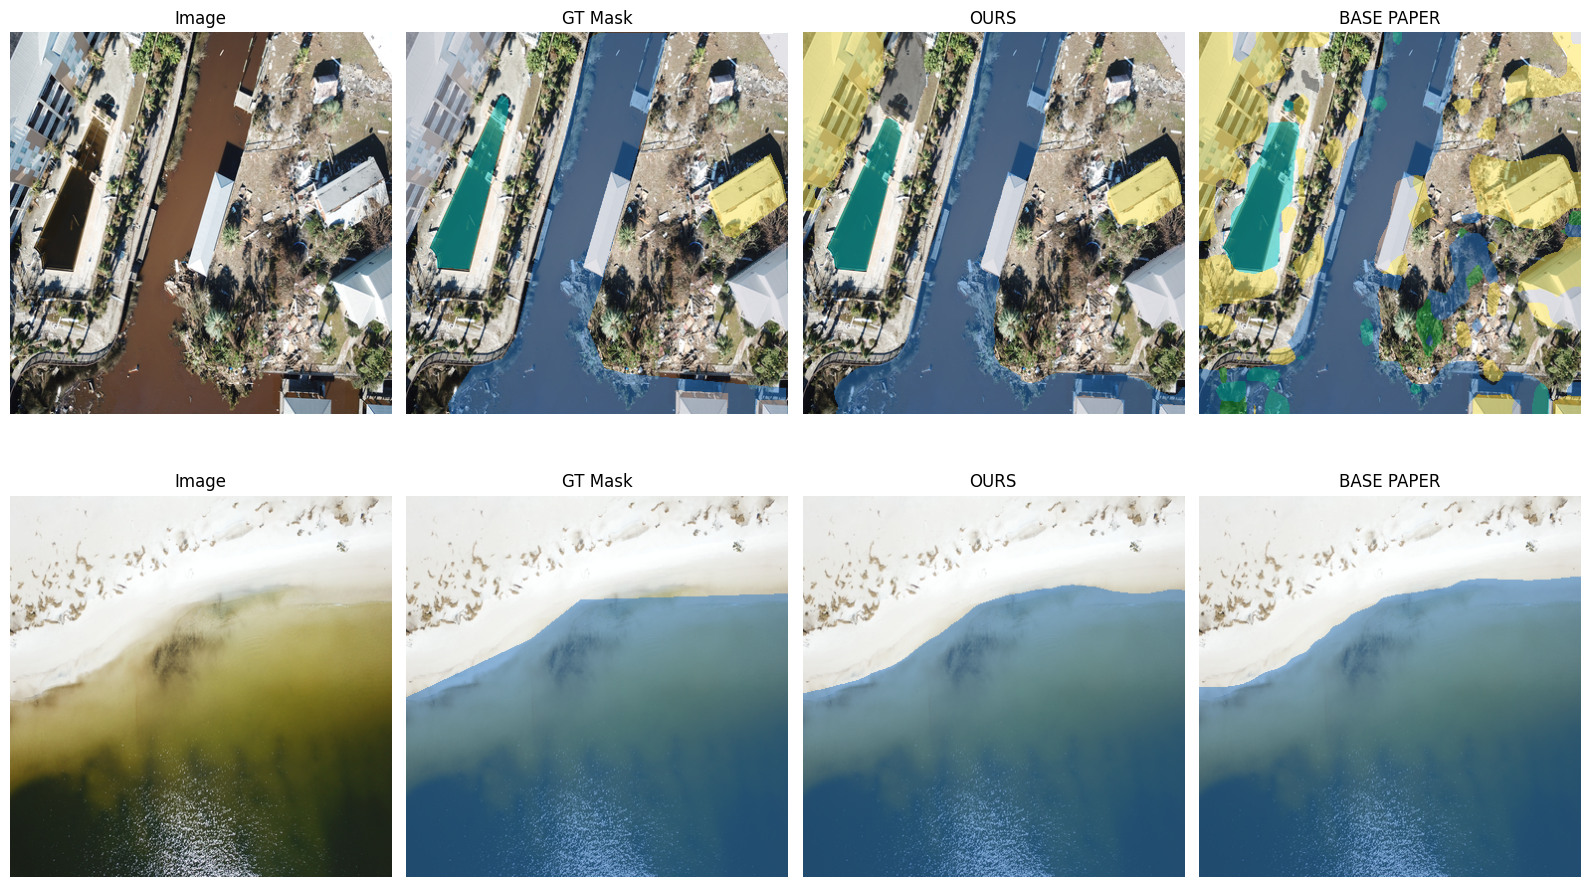

In [13]:
print("Our Model and Base Model Comparision")
model1Name = "OURS"
model2Name = "BASE PAPER"
compare_models(model1, model2, model1Name, model2Name, test_loader, device, num_samples=2)

Our Model Comparision with the Ground Truth Mask.


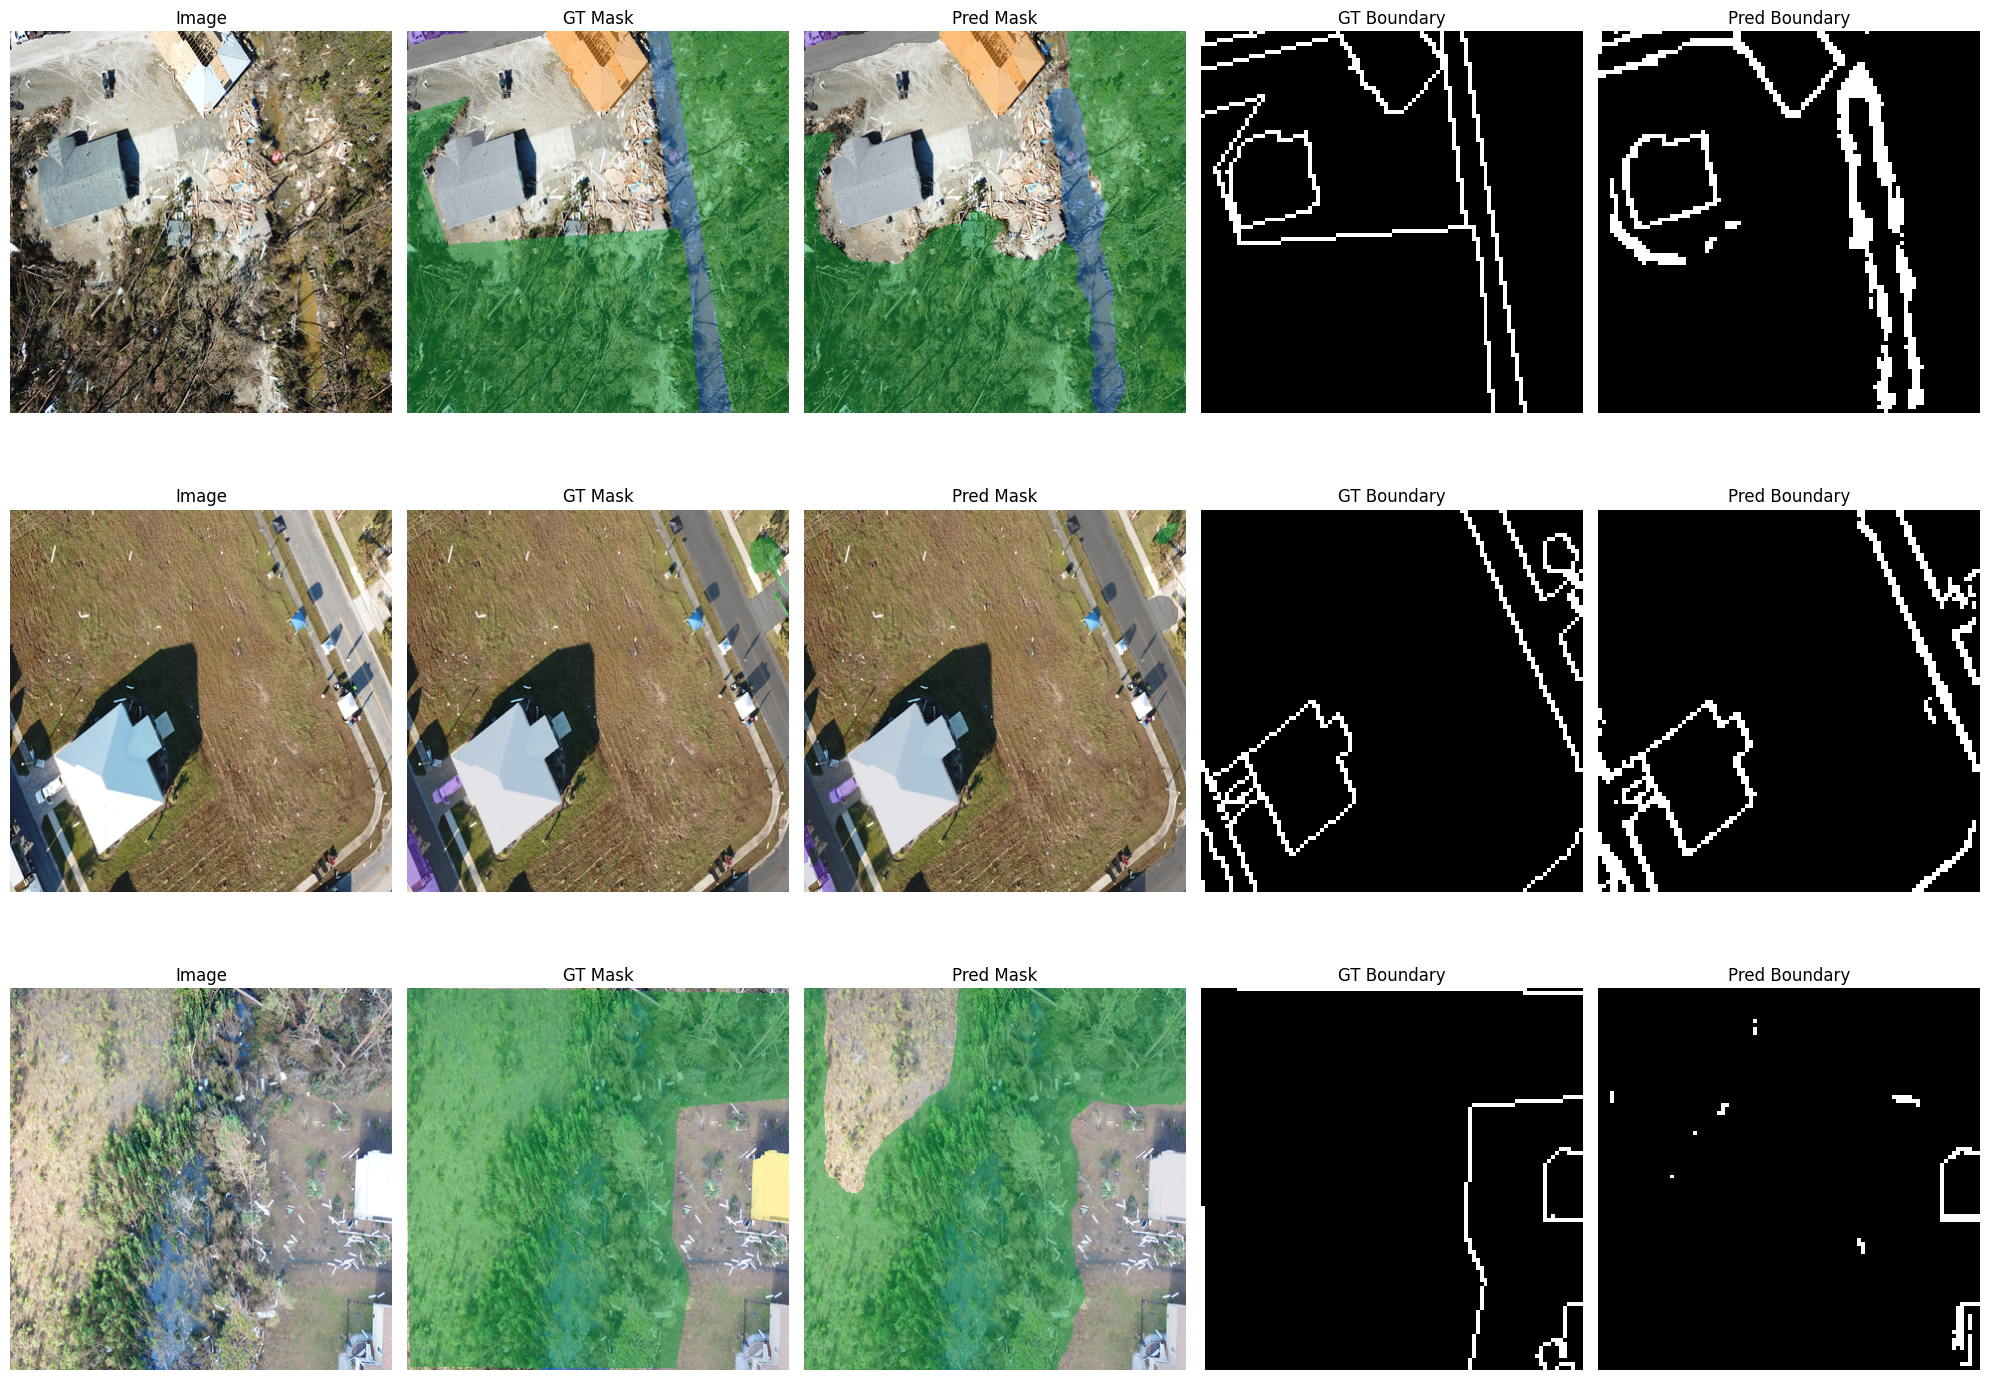

In [14]:
print("Our Model Comparision with the Ground Truth Mask.")
show_validation_examples(model1, test_loader, device, num_samples=3)

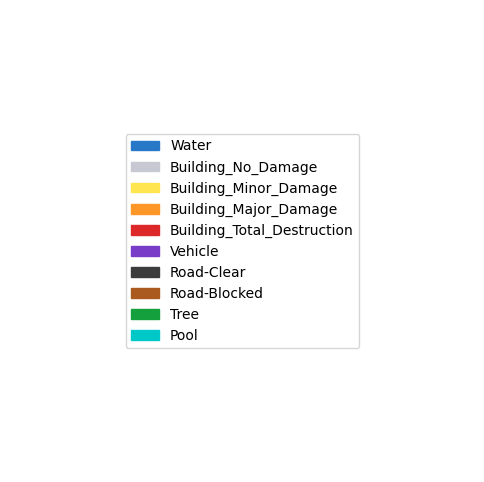

In [15]:
import matplotlib.patches as mpatches

CLASS_NAMES = [
    # 'Background',
    'Water',
    'Building_No_Damage',
    'Building_Minor_Damage',
    'Building_Major_Damage',
    'Building_Total_Destruction',
    'Vehicle',
    'Road-Clear',
    'Road-Blocked',
    'Tree',
    'Pool'
]

CLASS_COLORS = np.array([
    # [0, 0, 0],        # Background

    [40, 120, 200],   # Water → blue

    [200, 200, 210],  # Building_No_Damage → light cool gray
    [255, 230, 80],   # Building_Minor_Damage → yellow
    [255, 150, 40],   # Building_Major_Damage → orange
    [220, 40, 40],    # Building_Total_Destruction → red

    [120, 60, 200],   # Vehicle → purple (NOT green anymore)

    [60, 60, 60],     # Road-Clear → dark gray
    [170, 90, 30],    # Road-Blocked → strong brown (far from gray)

    [20, 160, 60],    # Tree → green (clearly different from vehicle now)

    [0, 200, 200]     # Pool → cyan (not same as water)
], dtype=np.uint8)


def show_legend():
    patches = [
        mpatches.Patch(color=CLASS_COLORS[i]/255.0, label=CLASS_NAMES[i])
        for i in range(len(CLASS_NAMES))
    ]

    plt.figure(figsize=(6, 6))
    plt.legend(handles=patches, loc='center')
    plt.axis('off')
    plt.show()

def show_legend_bar():
    fig, ax = plt.subplots(figsize=(10, 2))

    for i, (color, name) in enumerate(zip(CLASS_COLORS, CLASS_NAMES)):
        ax.barh(0, 1, left=i, color=color/255.0)
        ax.text(i + 0.5, 0, name, ha='center', va='center', fontsize=8)

    ax.set_xlim(0, len(CLASS_NAMES))
    ax.axis('off')
    plt.show()

def show_legend_grid():
    n = len(CLASS_NAMES)
    cols = 2
    rows = (n + cols - 1) // cols

    fig, ax = plt.subplots(figsize=(8, rows * 0.8))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.axis('off')

    for i, (color, name) in enumerate(zip(CLASS_COLORS, CLASS_NAMES)):
        r = rows - 1 - (i // cols)
        c = i % cols

        # color box
        ax.add_patch(plt.Rectangle((c, r), 0.3, 0.3, color=color/255.0))

        # text
        ax.text(c + 0.4, r + 0.15, name, va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

show_legend()
# show_legend_bar()
# show_legend_grid()